In [1]:
import functions as fct
import importlib
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


In [2]:
importlib.reload(fct)

<module 'functions' from 'C:\\Users\\User\\Documents\\Cours\\Stage\\functions.py'>

In [2]:
psd_p_19 , dates_p_19, freqs_p_19 = fct.load_psd("PSD_PII_2019-1-1_2019-12-31_RR.npz")
all_dates, median_psd_02_1=fct.median_plot(psd_p_19, dates_p_19, freqs_p_19, f1=0.2, f2=1, labell = "PII", plot=False, we = False, eq=False)
all_dates, median_psd_001_02=fct.median_plot(psd_p_19, dates_p_19, freqs_p_19, f1=0.2, f2=1, labell = "PII", plot=False, we = False, eq=False)
all_dates, median_psd_1_5=fct.median_plot(psd_p_19, dates_p_19, freqs_p_19, f1=1, f2=5, labell = "PII", plot=False, we = False, eq=False)


data= xr.open_dataset("virgo_ocean_2019_data.nc", engine='netcdf4')
    
wind = data["shww"]
wind_y,dates = fct.select_data(wind,"2019-01-01","2019-12-31", lat = 43.5, lon = 10.3)

swell = data['shts']
swell_y,dates = fct.select_data(swell,"2019-01-01","2019-12-31", lat = 43.5, lon = 10.3)



Calcul des médianes...


  0%|          | 0/8525 [00:00<?, ?it/s]

Calcul des médianes...


  0%|          | 0/8525 [00:00<?, ?it/s]

Calcul des médianes...


  0%|          | 0/8525 [00:00<?, ?it/s]

In [3]:
data_rain = xr.open_dataset('virgo_rain_2019.nc', engine='netcdf4')
rain = data_rain['tp']
rain_y,dates = fct.select_data(rain,"2019-01-01","2019-12-31")

In [4]:
df_psd_021 = pd.DataFrame(
    {"PSD021": median_psd_02_1},
    index=pd.to_datetime(all_dates)
)
df_psd_00102 = pd.DataFrame(
    {"PSD00102": median_psd_001_02},
    index=pd.to_datetime(all_dates)
)

df_wind = pd.DataFrame(
    {"Wind": wind_y},
    index=pd.to_datetime(dates)
)

df_swell = pd.DataFrame(
    {"Swell": swell_y},
    index=pd.to_datetime(dates)
)

In [5]:
df_rain = pd.DataFrame(
    {"Rain": rain_y},
    index=pd.to_datetime(dates)
)

In [6]:
df_day = pd.DataFrame(
    {"day": all_dates.weekday + 1},
    index=all_dates
)

df_hour = pd.DataFrame(
    {"Hour": all_dates.hour},
    index=all_dates
)

In [7]:
df_psd_15 = pd.DataFrame(
    {"PSD15": median_psd_1_5},
    index=pd.to_datetime(all_dates)
)

In [8]:
df = df_psd_021.join(df_psd_00102, how = "inner")
df = df.join(df_wind, how="inner")

df = df.join(df_swell, how="inner")

In [9]:
df = df.join(df_rain, how="inner")

In [10]:
df = df.join(df_hour, how="inner")
df = df.join(df_day, how="inner")


In [11]:
df = df.join(df_psd_15, how="inner")

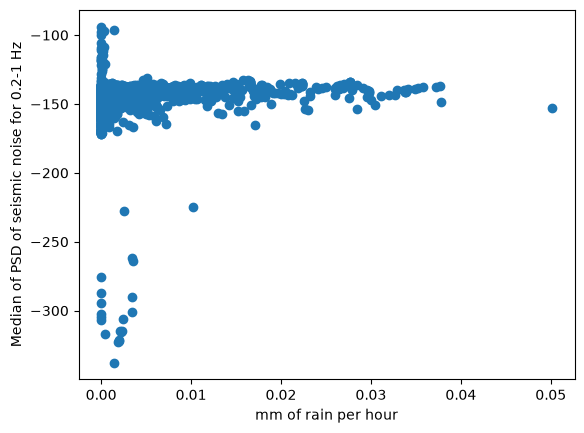

In [13]:
plt.scatter(df["Rain"],df["PSD021"])
plt.xlabel("mm of rain per hour")
plt.ylabel('Median of PSD of seismic noise for 0.2-1 Hz')
plt.show()

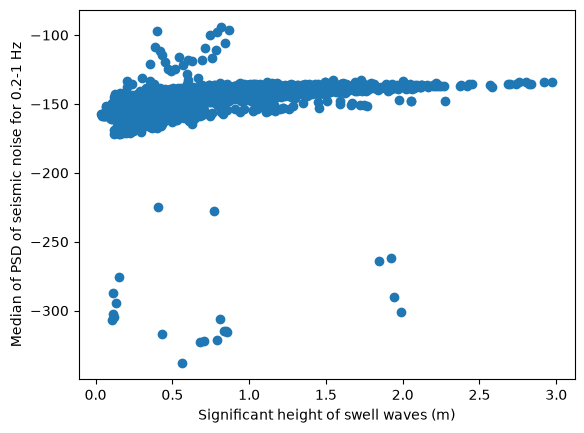

In [14]:
plt.scatter(df["Swell"],df["PSD021"])
plt.xlabel("Significant height of swell waves (m)")
plt.ylabel('Median of PSD of seismic noise for 0.2-1 Hz')
plt.show()

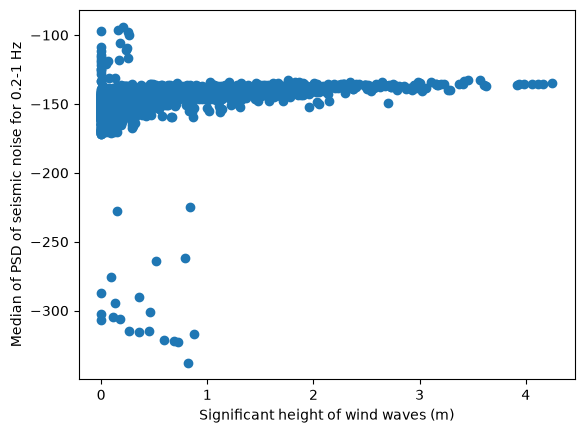

In [15]:
plt.scatter(df["Wind"],df["PSD021"])
plt.xlabel("Significant height of wind waves (m)")
plt.ylabel('Median of PSD of seismic noise for 0.2-1 Hz')
plt.show()

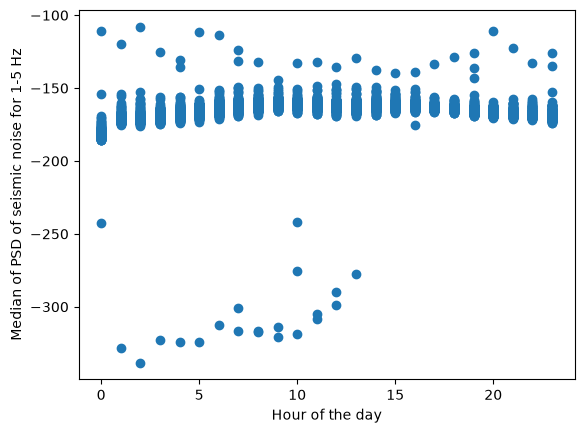

In [16]:
plt.scatter(df["Hour"],df["PSD15"])
plt.xlabel("Hour of the day")
plt.ylabel('Median of PSD of seismic noise for 1-5 Hz')
plt.show()

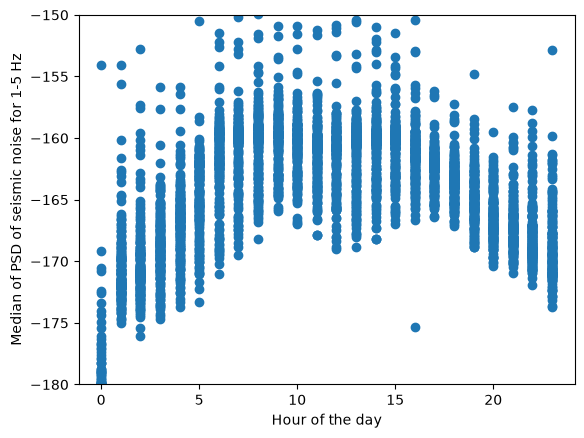

In [17]:
plt.scatter(df["Hour"],df["PSD15"])
plt.xlabel("Hour of the day")
plt.ylabel('Median of PSD of seismic noise for 1-5 Hz')
plt.ylim(-180,-150)
plt.show()

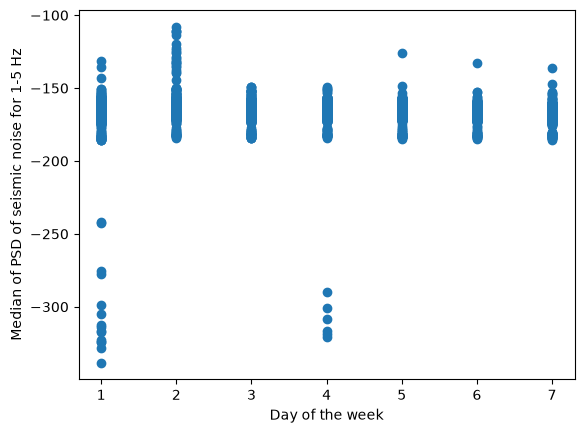

In [18]:
plt.scatter(df["day"],df["PSD15"])
plt.xlabel("Day of the week")
plt.ylabel('Median of PSD of seismic noise for 1-5 Hz')
plt.show()

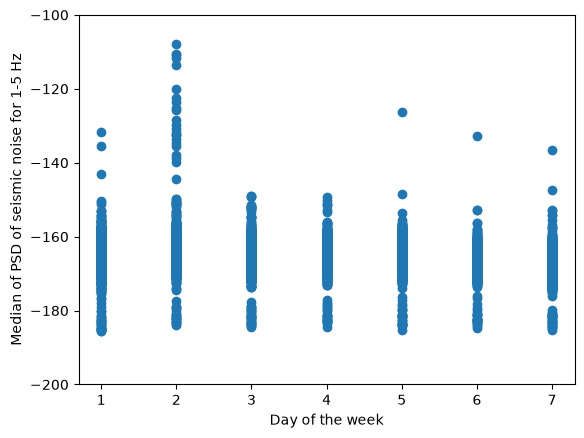

In [19]:
plt.scatter(df["day"],df["PSD15"])
plt.xlabel("Day of the week")
plt.ylabel('Median of PSD of seismic noise for 1-5 Hz')
plt.ylim(-200,-100)
plt.show()

In [24]:
hour_points = df[["Hour","PSD15"]]
hour_median = df.groupby("Hour")["PSD15"].median()
print(np.size(hour_points))

8986


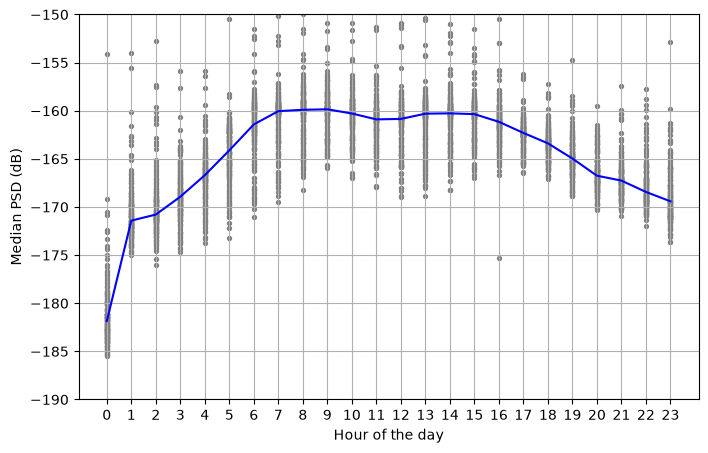

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(
    hour_points['Hour'],
    hour_points['PSD15'], color = "grey", s=8)
plt.plot(hour_median.index, hour_median.values,color = "blue") 

plt.xlabel("Hour of the day")
plt.ylabel("Median PSD (dB)")
plt.xticks(range(24))
plt.ylim(-190,-150)
plt.grid()
plt.show()

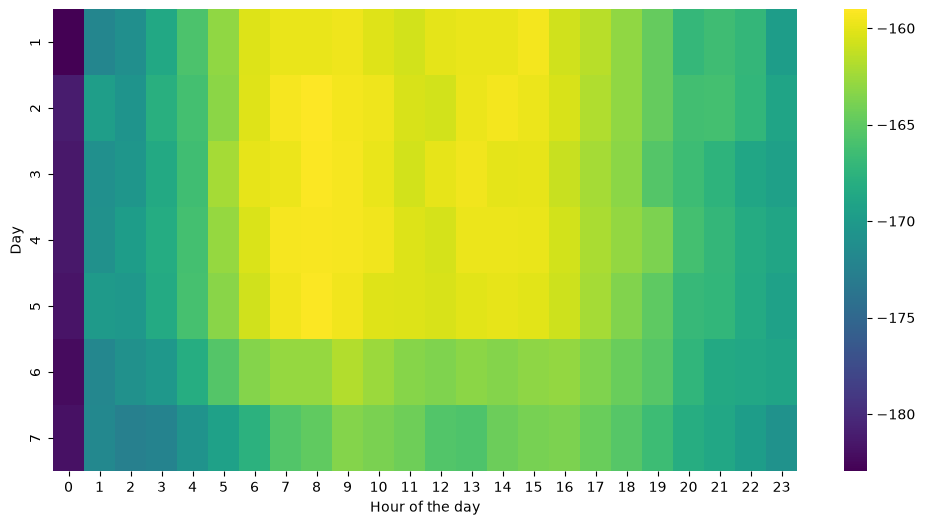

In [34]:
import seaborn as sns

pivot = df.pivot_table(
    index="day",      # ou date
    columns="Hour",
    values="PSD15",
    aggfunc="median"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="viridis")
plt.xlabel("Hour of the day")
plt.ylabel("Day")
plt.show()


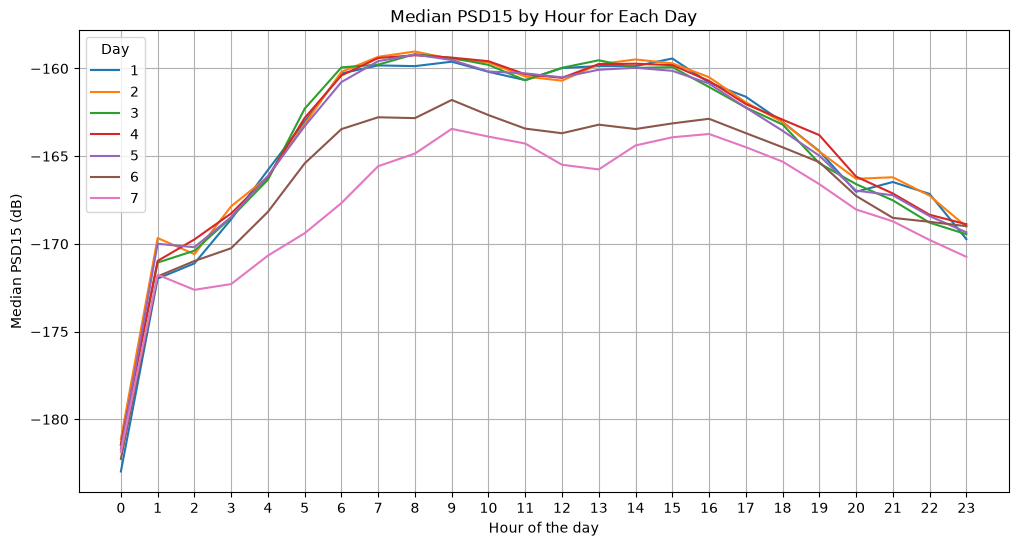

In [39]:
grouped = df.groupby(["day", "Hour"])["PSD15"].median().reset_index()

plt.figure(figsize=(12,6))

for day, sub in grouped.groupby("day"):
    plt.plot(sub["Hour"], sub["PSD15"], label=str(day))

plt.xlabel("Hour of the day")
plt.ylabel("Median PSD15 (dB)")
plt.xticks(range(24))
plt.grid()
plt.legend(title="Day")
plt.title("Median PSD15 by Hour for Each Day")
plt.show()


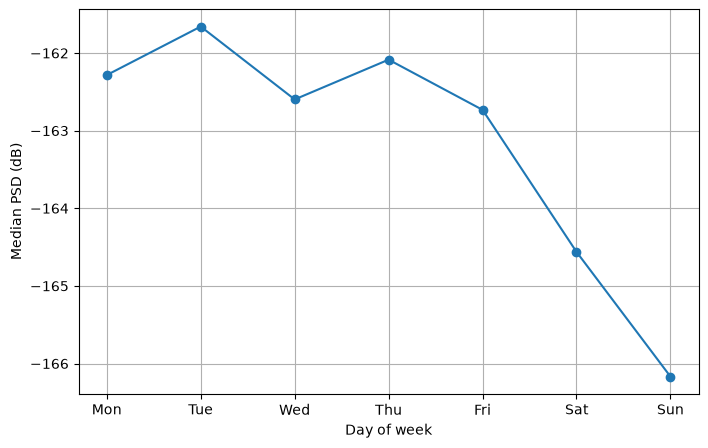

In [21]:
day_median = df.groupby("day")["PSD15"].median()

plt.figure(figsize=(8,5))
plt.plot(day_median.index, day_median.values, marker="o")

plt.xticks(
    range(1,8),
    ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
)

plt.ylabel("Median PSD (dB)")
plt.xlabel("Day of week")
plt.grid()
plt.show()

Calcul des médianes...


  0%|          | 0/8525 [00:00<?, ?it/s]

Calcul des médianes...


  0%|          | 0/8525 [00:00<?, ?it/s]

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

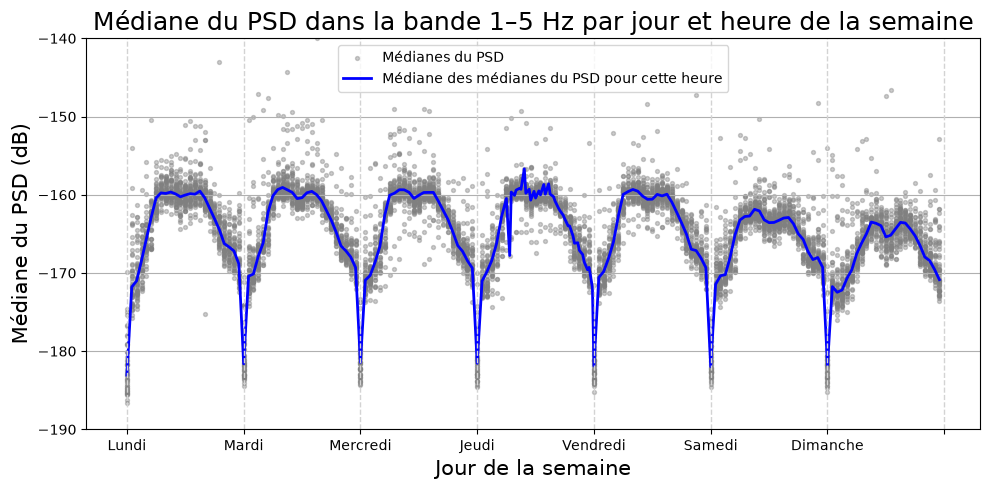

In [1]:
import functions as fct
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Chargement des données
# ==========================================================

psd_p_19, dates_p_19, freqs_p_19 = fct.load_psd(
    "PSD_PII_2019-1-1_2019-12-31_RR.npz"
)

# ==========================================================
# Médianes PSD
# ==========================================================

all_dates, median_psd_021 = fct.median_plot(
    psd_p_19,
    dates_p_19,
    freqs_p_19,
    f1=0.2,
    f2=1,
    labell="PII",
    plot=False,
)

all_dates, median_psd_15 = fct.median_plot(
    psd_p_19,
    dates_p_19,
    freqs_p_19,
    f1=1,
    f2=5,
    labell="PII",
    plot=False,
)

# ==========================================================
# DataFrame
# ==========================================================

df = pd.DataFrame(
    {
        "PSD021": median_psd_021,
        "PSD15": median_psd_15,
    },
    index=pd.to_datetime(all_dates)
)

# Heure de la semaine (0 -> 168 h)
df["week_hour"] = (
    df.index.weekday * 24
    + df.index.hour
    + df.index.minute / 60
)

# ==========================================================
# Calcul de la médiane
# ==========================================================

hour_points = df[["week_hour", "PSD15"]]

hour_median = (
    df.groupby("week_hour")["PSD15"]
    .median()
)

# ==========================================================
# Figure
# ==========================================================

plt.figure(figsize=(10,5))

plt.scatter(
    hour_points["week_hour"],
    hour_points["PSD15"],
    color="grey",
    s=8,
    alpha=0.4, label = "Médianes du PSD"
)

plt.plot(
    hour_median.index,
    hour_median.values,
    color="blue",
    linewidth=2,
    label="Médiane des médianes du PSD pour cette heure"
)

# Lignes verticales séparant les jours
for h in range(0, 169, 24):
    plt.axvline(
        h,
        color="lightgrey",
        linestyle="--",
        linewidth=1
    )

plt.xticks(
    np.arange(0, 169, 24),
    ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche", ""]
)

plt.xlabel("Jour de la semaine",size=15)
plt.ylabel("Médiane du PSD (dB)",size=15)
plt.title("Médiane du PSD dans la bande 1–5 Hz par jour et heure de la semaine",size=18)
plt.grid(axis="y")
plt.ylim(-190, -140)

plt.legend()

plt.tight_layout()
plt.savefig("medianemediane.png", dpi=300, bbox_inches="tight")

plt.show()

In [22]:
psd_19 , dates_19, freqs_19 = fct.load_psd("PSD_VRG01_2019.npz")
all_dates, median_psd_02_1=fct.median_plot(psd_19, dates_19, freqs_19, f1=0.2, f2=1,  plot=False, we = False, eq=False)
all_dates, median_psd_001_02=fct.median_plot(psd_19, dates_19, freqs_19, f1=0.2, f2=1, plot=False, we = False, eq=False)
all_dates, median_psd_1_5=fct.median_plot(psd_19, dates_19, freqs_19, f1=1, f2=5,  plot=False, we = False, eq=False)


data= xr.open_dataset("virgo_ocean_2019_data.nc", engine='netcdf4')
    
wind = data["shww"]
wind_y,dates = fct.select_data(wind,"2019-01-01","2019-12-31", lat = 43.5, lon = 10.3)

swell = data['shts']
swell_y,dates = fct.select_data(swell,"2019-01-01","2019-12-31", lat = 43.5, lon = 10.3)

data_rain = xr.open_dataset('virgo_rain_2019.nc', engine='netcdf4')
rain = data_rain['tp']
rain_y,dates = fct.select_data(rain,"2019-01-01","2019-12-31")


Calculating medians...


  0%|          | 0/4602 [00:00<?, ?it/s]

Calculating medians...


  0%|          | 0/4602 [00:00<?, ?it/s]

Calculating medians...


  0%|          | 0/4602 [00:00<?, ?it/s]

In [23]:
df_psd_021 = pd.DataFrame(
    {"PSD021": median_psd_02_1},
    index=pd.to_datetime(all_dates)
)
df_psd_00102 = pd.DataFrame(
    {"PSD00102": median_psd_001_02},
    index=pd.to_datetime(all_dates)
)

df_wind = pd.DataFrame(
    {"Wind": wind_y},
    index=pd.to_datetime(dates)
)

df_swell = pd.DataFrame(
    {"Swell": swell_y},
    index=pd.to_datetime(dates)
)

df_rain = pd.DataFrame(
    {"Rain": rain_y},
    index=pd.to_datetime(dates)
)

df_day = pd.DataFrame(
    {"day": all_dates.weekday + 1},
    index=all_dates
)

df_hour = pd.DataFrame(
    {"Hour": all_dates.hour},
    index=all_dates
)

df_psd_15 = pd.DataFrame(
    {"PSD15": median_psd_1_5},
    index=pd.to_datetime(all_dates)
)



In [24]:
df = df_psd_021.join(df_psd_00102, how = "inner")
df = df.join(df_wind, how="inner")

df = df.join(df_swell, how="inner")
df = df.join(df_rain, how="inner")
df = df.join(df_psd_15, how="inner")
df = df.join(df_day, how="inner")
df = df.join(df_hour, how="inner")

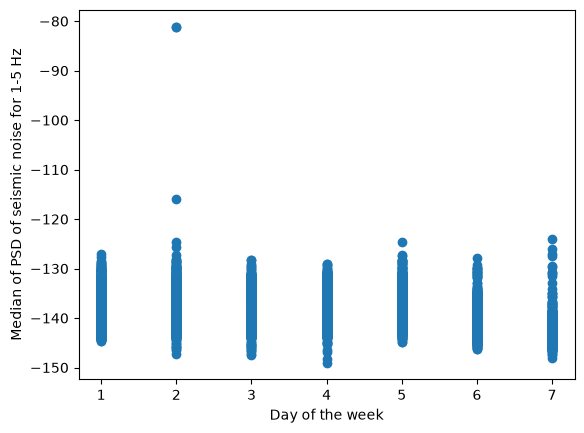

In [25]:
plt.scatter(df["day"],df["PSD15"])
plt.xlabel("Day of the week")
plt.ylabel('Median of PSD of seismic noise for 1-5 Hz')
#plt.ylim(-160,-110)
plt.show()

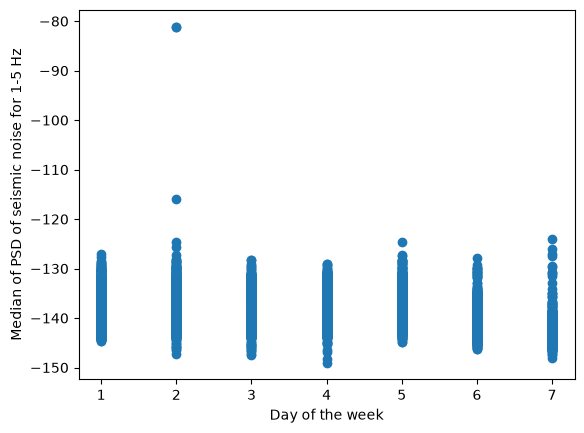

In [26]:
plt.scatter(df["day"],df["PSD15"])
plt.xlabel("Day of the week")
plt.ylabel('Median of PSD of seismic noise for 1-5 Hz')
plt.show()

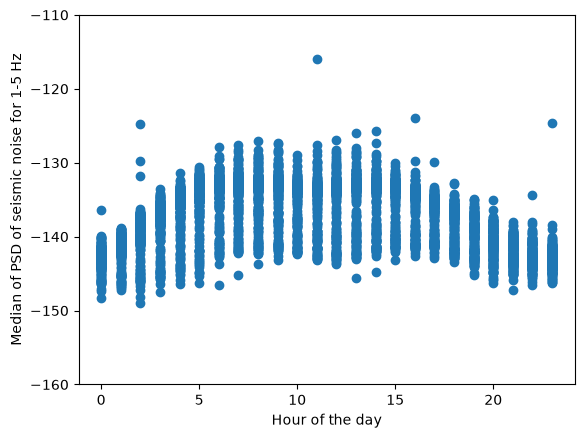

In [27]:
plt.scatter(df["Hour"],df["PSD15"])
plt.xlabel("Hour of the day")
plt.ylabel('Median of PSD of seismic noise for 1-5 Hz')
plt.ylim(-160,-110)
plt.show()

In [28]:
df

,PSD021,PSD00102,Wind,Swell,Rain,PSD15,day,Hour
2019-06-22 00:00:00,-130.835510,-130.835510,1.347656e-01,0.377563,8.702277e-07,-142.400208,6,0
2019-06-22 01:00:00,-128.765564,-128.765564,2.490234e-02,0.387288,0.000000e+00,-141.431381,6,1
2019-06-22 02:00:00,-128.383133,-128.383133,2.548868e-16,0.377197,0.000000e+00,-141.037262,6,2
2019-06-22 03:00:00,-129.090820,-129.090820,1.779785e-01,0.334080,7.078052e-06,-138.459991,6,3
2019-06-22 04:00:00,-128.491714,-128.491714,3.967285e-01,0.102417,4.331768e-05,-136.198120,6,4
...,...,...,...,...,...,...,...,...
2019-12-31 19:00:00,-135.893906,-135.893906,6.909180e-02,0.173113,8.523463e-07,-143.552963,2,19
2019-12-31 20:00:00,-136.170929,-136.170929,1.171875e-01,0.169391,8.523463e-07,-146.234421,2,20
2019-12-31 21:00:00,-134.902008,-134.902008,1.340332e-01,0.176697,8.523463e-07,-147.201950,2,21
2019-12-31 22:00:00,-133.504669,-133.504669,1.899414e-01,0.155518,8.523463e-07,-146.476318,2,22


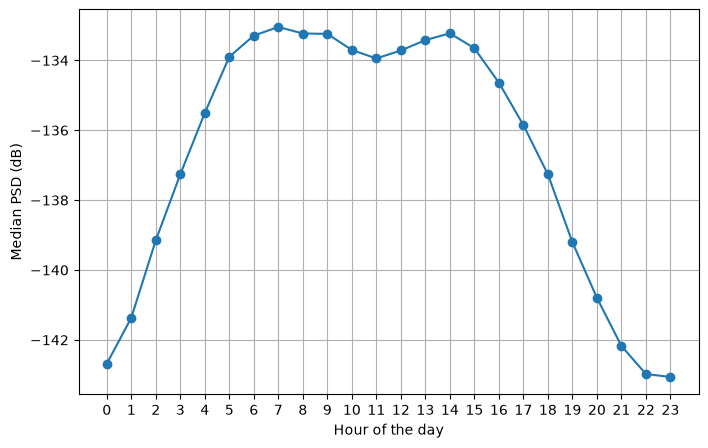

In [29]:
hour_median = df.groupby("Hour")["PSD15"].median()

plt.figure(figsize=(8,5))
plt.plot(
    hour_median.index,
    hour_median.values,
    marker="o"
)

plt.xlabel("Hour of the day")
plt.ylabel("Median PSD (dB)")
plt.xticks(range(24))
plt.grid()
plt.show()

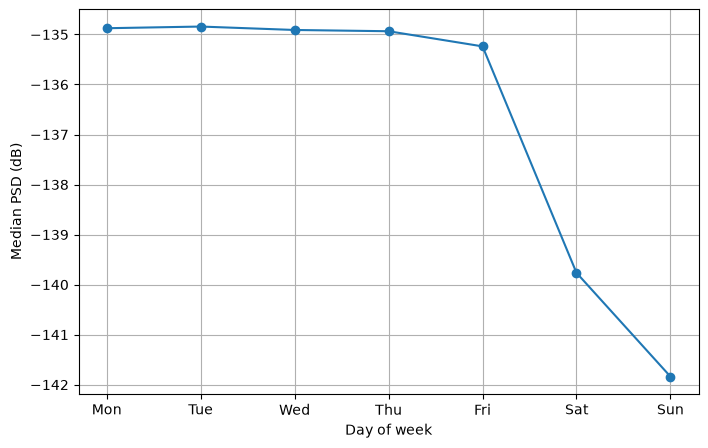

In [30]:
day_median = df.groupby("day")["PSD15"].median()

plt.figure(figsize=(8,5))
plt.plot(day_median.index, day_median.values, marker="o")

plt.xticks(
    range(1,8),
    ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
)

plt.ylabel("Median PSD (dB)")
plt.xlabel("Day of week")
plt.grid()
plt.show()

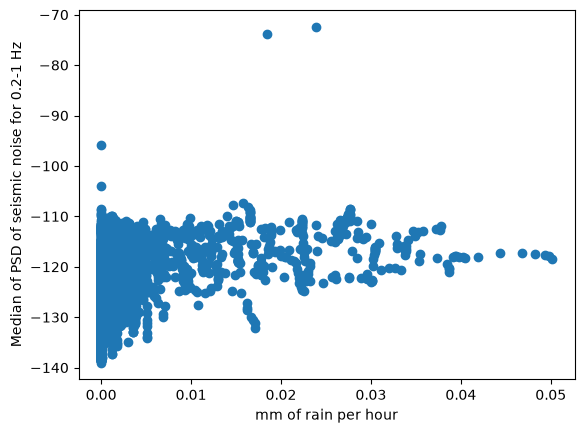

In [31]:
plt.scatter(df["Rain"],df["PSD021"])
plt.xlabel("mm of rain per hour")
plt.ylabel('Median of PSD of seismic noise for 0.2-1 Hz')
plt.show()

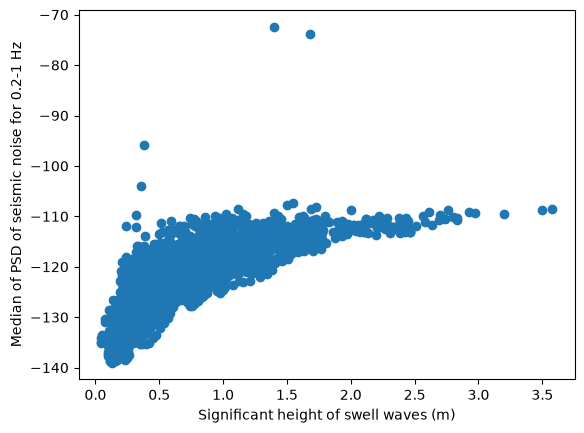

In [32]:
plt.scatter(df["Swell"],df["PSD021"])
plt.xlabel("Significant height of swell waves (m)")
plt.ylabel('Median of PSD of seismic noise for 0.2-1 Hz')
plt.show()

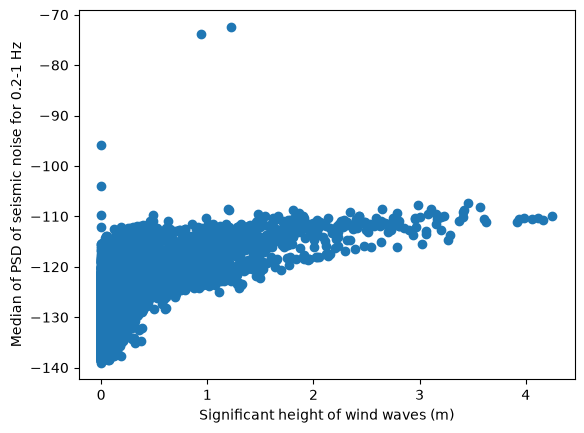

In [33]:
plt.scatter(df["Wind"],df["PSD021"])
plt.xlabel("Significant height of wind waves (m)")
plt.ylabel('Median of PSD of seismic noise for 0.2-1 Hz')
plt.show()